In [ ]:
!pip install matplotlib scipy h5py numpy

In [35]:
# =================================================================
# 2. IMPORTS
# =================================================================
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.ticker import LogFormatterExponent
import matplotlib.ticker as mticker
from numpy import unravel_index
import astropy.units as u
import math
from IPython.display import clear_output
import time
from scipy.ndimage import rotate
from scipy.interpolate import RegularGridInterpolator
import h5py
from pathlib import Path
from matplotlib.patches import Circle
from importlib import reload
from google.colab import drive
import os

# Mount Google Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [36]:
drive_dir = "/content/drive/MyDrive/"
diskimage_dir = 'Roman_winter_school/Morphology/'
diskmodel_path = os.path.join(drive_dir,diskimage_dir)

Function to plot the scattered light and thermal emission at different wavelength

In [22]:
def plot_image(diskmodel_path,diskfile,wave,index=5):


  filename=diskmodel_path+diskfile
  px=py=256
  with fits.open(filename) as hdul:
    image=hdul[0].data[index].reshape(px,py)

  # 3. psf scale
  psf_scale = 0.2184  # arcsecs/pixel
  sq_as_per_pix = psf_scale**2
  c=2.99792*10**14
  jy=10**26
  px=256
  py=256
  psf_scale=0.02182 ##arcsecs/pixel
  xpix=(np.arange (-px/2, px/2, 1))*psf_scale
  ypix=(np.arange (-px/2, px/2, 1))*psf_scale

  disk_sb=(image*1000/c)*wave*jy/(sq_as_per_pix)

  fig = plt.figure(dpi=125)
  ax1=fig.add_subplot(111)
  ax1.yaxis.set_ticks_position('both')
  ax1.xaxis.set_ticks_position('both')
  ax1.minorticks_on()
  ax1.tick_params(which='both', direction='in', width=0.5,labelsize=12)
  im1=ax1.imshow(disk_sb.astype(np.float64),cmap='magma',extent=[np.min(xpix),np.max(xpix),np.max(ypix),np.min(ypix)])
  ax1.invert_yaxis()
  ax1.set_ylabel('y [arcsec]',fontsize=12)
  ax1.set_xlabel('x [arcsec]',fontsize=12)
  ax1.set_title('Total intensity',fontsize=12)
  cb = fig.colorbar(im1,orientation='vertical')
  cb.ax.tick_params(labelsize=12)
  cb.set_label("$mJy/arcsec^2$",fontsize=12)

  return


Let's see how the disk looks through HST/Roman - in optical - note - for scattered light from the star, we use index=5

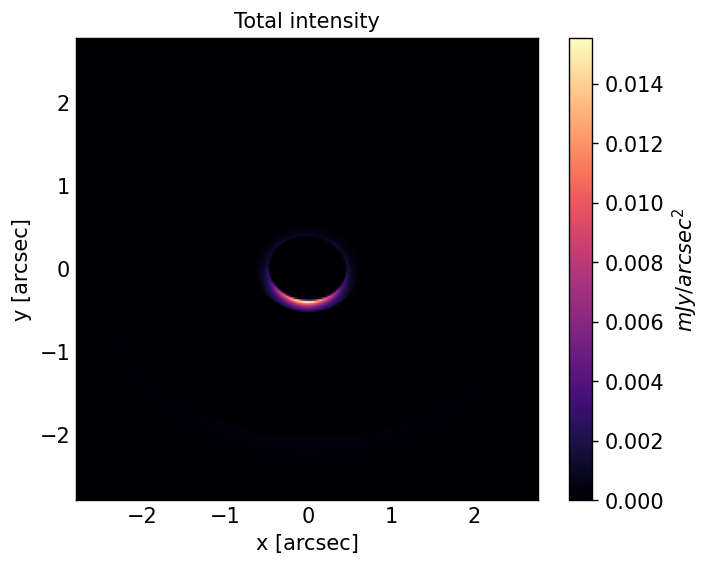

In [29]:
#MCFOST files have 8 images in one cube corresponding to I, Q, U, V, Star alone, scattered light from the star, thermal emission, scattered light from the dust thermal emission
diskfile='eps_eri_0.6micron.fits'
wave=0.6 ## microns
plot_image(diskmodel_path,diskfile,wave,index=5)

Let's see how the disk looks through JWST - for thermal emission we use index=6

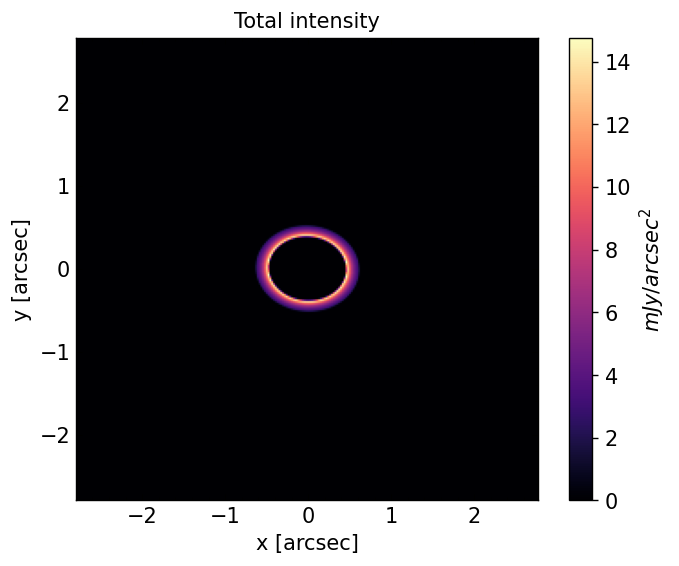

In [30]:
diskfile='eps_eri_25micron.fits'
wave=25 ## microns
plot_image(diskmodel_path,diskfile,wave,index=6)

Let's see how the disk looks through ALMA - radio observation - for thermal emission we use index=6

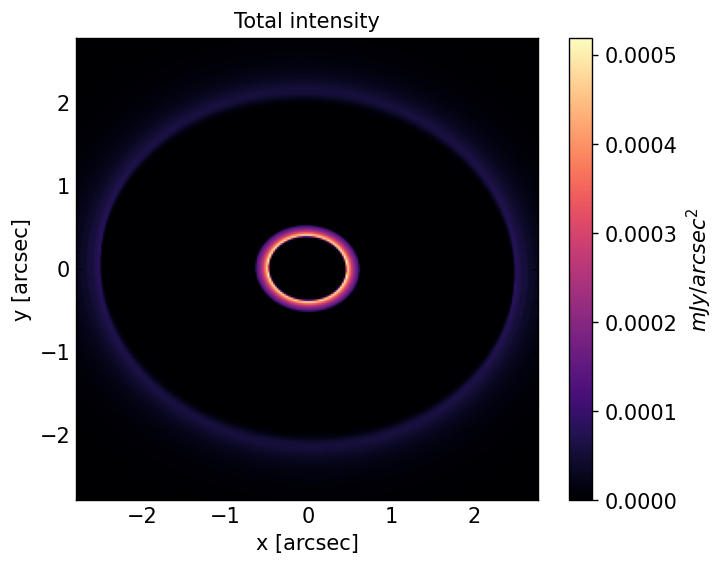

In [32]:
diskfile='eps_eri_1300micron.fits'
wave=1300 ## microns
plot_image(diskmodel_path,diskfile,wave,index=6)

** Q What differences did you see in the above observations in terms of debris disks sytem morphology?**

Now we will look at another disk at optical and mid-ir wavelengths

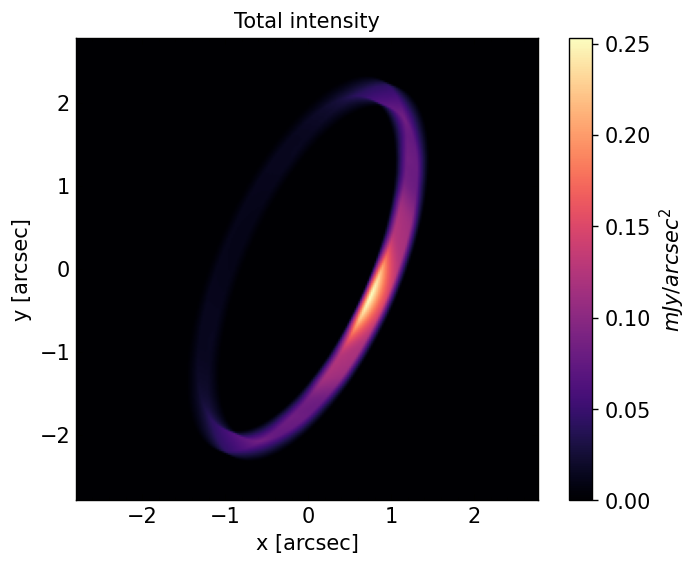

In [37]:
diskfile='fomalhaut_0.6micron.fits'
wave=0.6 ## microns
plot_image(diskmodel_path,diskfile,wave,index=5)

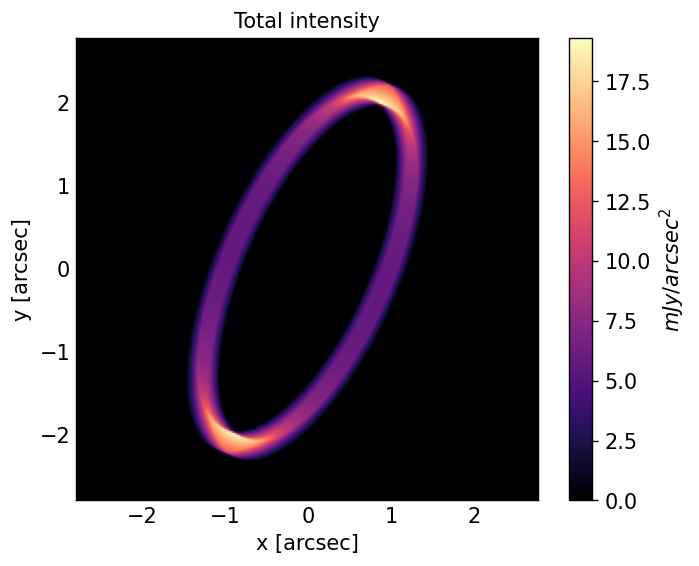

In [39]:
diskfile='fomalhaut_25micron.fits'
wave=25 ## microns
plot_image(diskmodel_path,diskfile,wave,index=6)

In [51]:
filename=diskmodel_path+'fomalhaut_0.6micron.fits'
wav=0.6 ## microns
# read the fits file
with fits.open(filename) as hdul:
      I  = hdul[0].data[0].reshape(256,256)
      Q  = hdul[0].data[1].reshape(256,256)
      U  = hdul[0].data[2].reshape(256,256)
      V  = hdul[0].data[3].reshape(256,256)
      sst=hdul[0].data[5].reshape(256,256)
      dth=hdul[0].data[6]
# 3. psf scale
psf_scale = 0.2184  # arcsecs/pixel
sq_as_per_pix = psf_scale**2
c=2.99792*10**14
jy=10**26

# convert the fluxes to mjy/arcsec^2
I_jy=sst
Q_jy=Q
U_jy=U
V_jy=V





Let's look at the total intensity and Stokes parameters

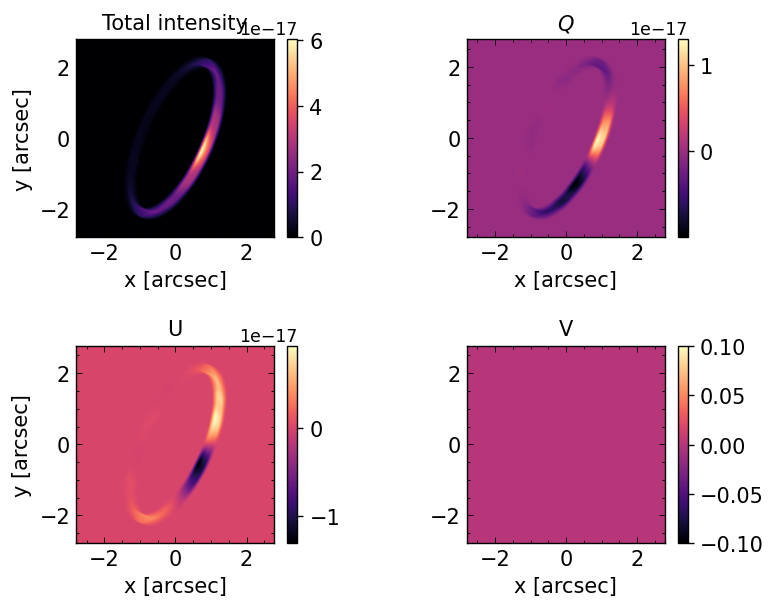

In [53]:
px=256
py=256
psf_scale=0.02182 ##arcsecs/pixel
xpix=(np.arange (-px/2, px/2, 1))*psf_scale
ypix=(np.arange (-px/2, px/2, 1))*psf_scale

fig = plt.figure(dpi=125)
ax1=fig.add_subplot(221)
ax1.yaxis.set_ticks_position('both')
ax1.xaxis.set_ticks_position('both')
ax1.minorticks_on()
ax1.tick_params(which='both', direction='in', width=0.5,labelsize=12)
im1=ax1.imshow(I_jy.astype(np.float64),cmap='magma',extent=[np.min(xpix),np.max(xpix),np.max(ypix),np.min(ypix)])
ax1.invert_yaxis()
ax1.set_ylabel('y [arcsec]',fontsize=12)
ax1.set_xlabel('x [arcsec]',fontsize=12)
ax1.set_title('Total intensity',fontsize=12)
cb = fig.colorbar(im1,orientation='vertical')
cb.ax.tick_params(labelsize=12)

ax2=fig.add_subplot(222)
ax2.yaxis.set_ticks_position('both')
ax2.xaxis.set_ticks_position('both')
ax2.minorticks_on()
ax2.tick_params(which='both', direction='in', width=0.5,labelsize=12)
im2=ax2.imshow(Q_jy.astype(np.float64),cmap='magma',extent=[np.min(xpix),np.max(xpix),np.max(ypix),np.min(ypix)])
ax2.invert_yaxis()
#ax2.set_ylabel('y [arcsec]')
ax2.set_xlabel('x [arcsec]',fontsize=12)
ax2.set_title(r'$Q$',fontsize=12)
cb = fig.colorbar(im2,orientation='vertical')
cb.ax.tick_params(labelsize=12)


ax1=fig.add_subplot(223)
ax1.yaxis.set_ticks_position('both')
ax1.xaxis.set_ticks_position('both')
ax1.minorticks_on()
ax1.tick_params(which='both', direction='in', width=0.5,labelsize=12)
im1=ax1.imshow(U_jy.astype(np.float64),cmap='magma',extent=[np.min(xpix),np.max(xpix),np.max(ypix),np.min(ypix)])
ax1.invert_yaxis()
ax1.set_ylabel('y [arcsec]',fontsize=12)
ax1.set_xlabel('x [arcsec]',fontsize=12)
ax1.set_title('U',fontsize=12)
cb = fig.colorbar(im1,orientation='vertical')
cb.ax.tick_params(labelsize=12)

ax1=fig.add_subplot(224)
ax1.yaxis.set_ticks_position('both')
ax1.xaxis.set_ticks_position('both')
ax1.minorticks_on()
ax1.tick_params(which='both', direction='in', width=0.5,labelsize=12)
im1=ax1.imshow(V_jy.astype(np.float64),cmap='magma',extent=[np.min(xpix),np.max(xpix),np.max(ypix),np.min(ypix)])
ax1.invert_yaxis()
#ax1.set_ylabel('y [arcsec]')
ax1.set_xlabel('x [arcsec]',fontsize=12)
ax1.set_title('V',fontsize=12)
cb = fig.colorbar(im1,orientation='vertical')
cb.ax.tick_params(labelsize=12)

fig.subplots_adjust(hspace=0.55, wspace=0.45, top=0.95, right=0.95)